## PS 1

#### Import packages and define parameters

In [1]:
using Plots
using Printf
using Statistics

In [2]:
Base.@kwdef struct EconomicParameters
    α::Float64 = 0.3          # capital share
    β::Float64 = 0.96         # discount factor
    δ::Float64 = 1.0          # depreciation rate
    γ::Float64 = 1.0          # risk aversion
end

EconomicParameters

In [3]:
Base.@kwdef struct NumericalParameters
    nk::Int = 200             # N points on the grid
    kmin_rel::Float64 = 0.1   # lower grid bound, relative to k*
    kmax_rel::Float64 = 2.0   # upper grid bound, relative to k*
    spacing::Symbol = :linear # :linear or :log for the spacing of points on the grid
    crit::Float64 = 1e-6      # convergence tolerance, ε
    maxiter::Int = 5000       # iteration cap, the safety net
end

NumericalParameters

In [4]:
par = EconomicParameters()
mpar = NumericalParameters()
println("Economic parameters:  ", par)
println("Numerical parameters: ", mpar)

Economic parameters:  EconomicParameters(0.3, 0.96, 1.0, 1.0)
Numerical parameters: NumericalParameters(200, 0.1, 2.0, :linear, 1.0e-6, 5000)


#### Solve the model numerically

The steady state capital is obtained from the Euler equation setting $c=c'$ and $k=k'$

$$
c^{-\gamma}=\beta(\alpha  k^{\alpha -1}+1-\delta)c^{-\gamma}
$$
$$
1 = \beta(\alpha  k^{\alpha -1}+1-\delta)
$$
$$
k^* = (\frac{\alpha}{\frac{1}{\beta}-1+\delta})^{\frac{1}{1-\alpha}}
$$

The utility is given by:

$u(c) = \frac{c^{1-\gamma}-1}{1-\gamma}$; when $\gamma=1$ then $u(c)=ln(c)$

In [5]:
function util(c, par)
    if par.γ != 1.0
        return (c^(1-par.γ)-1)/(1-par.γ)
    else
        return log(c)
    end
end

util (generic function with 1 method)

Consumption is defined through the budget constraint, for each possible combination of $k_i$ and $k'_j$: at state $k_i$ the household has output $k_i^\alpha + (1-\delta)k_i$ to spend; choosing $k'_j$ leaves consumption

$$
C_{ij} = k_i^\alpha + (1-\delta)k_i  - k'_j .
$$

A pair with $C_{ij} \leq 0$ is infeasible. To implement this in the computer, we define the reward matrix U as follows:

$$
U_{ij} = \begin{cases} u(C_{ij}) & \text{if } C_{ij} > 0, \\ -\infty & \text{otherwise.} \end{cases}
$$

such that negative or zero consumption is never chosen in the optimum.

In [6]:
function solver(par,mpar)

    @printf("Value function iteration with parameters alpha = %.1f, beta = %.2f, gamma = %.1f, delta = %.1f, N = %d, crit = %.0e\n", par.α, par.β, par.γ, par.δ, mpar.nk, mpar.crit)

     # ----- steady state and grid -----

    kstar = (par.α / (1/par.β - 1 + par.δ))^(1/(1-par.α))                                  
    kmin, kmax = mpar.kmin_rel * kstar, mpar.kmax_rel * kstar
    
    if mpar.spacing == :linear
    gri = (k = collect(range(kmin,kmax, length=mpar.nk)),)
    else                                         
    gri = (k = exp.(range(log(kmin), log(kmax), length = mpar.nk)),)
    end

    # ----- state-choice meshes -----

    meshes = (
    k      = [k  for k in gri.k, kP in gri.k],                  # 200 x 200 matrix
    kprime = [kP for k in gri.k, kP in gri.k],                  # 200 x 200 matrix
    )
    
    # ----- consumption and utility matrices -----
    
    C = meshes.k .^ par.α .+ (1-par.δ) .* meshes.k .- meshes.kprime                                    # 200 x 200 matrix
    U = fill(-Inf, size(C))
    U[C .> 0] = util.(C[C .> 0], Ref(par))

    # ----- value function iteration -----

    v      = zeros(mpar.nk)                      # the guess v_0 = 0 for each state k (200-element Vector)
    g      = ones(Int, mpar.nk)                  # the policy as grid indices (integers), 200-element Vector (one optimal k' for each k)
    distVF = [Inf]                               # one element vector, containing Inf
    iterVF = 0 

    while distVF[end]> mpar.crit && iterVF < mpar.maxiter          
                         
        M    = U .+ par.β .* v'                  # each elements in a row of U, corresponding to a fixed state k and different k', is summed to the corresponding element of the horizonal vector v(k')
        vals, idx = findmax(M, dims = 2)         # find the maximum along each row (dims=2), so along each possible state k. In other words, for each row k, find the k' (the column) which maximises M
                                                 # returns the value and index for each row
        vnew = vec(vals)                         # store in a column vectors the value functions (each row has the value function for a different k)
        g    = vec(getindex.(idx, 2))            # idx holds a CartesianIndex (i, j) per row: getindex.(idx, 2) picks the column j, vec turns it into a column vector 
                                                 # --> g is a col vec where each row corresponds to a different k, and the number represents the column index with which to extract the k-specific maximiser k'
        dd   = maximum(abs.(vnew .- v))          # distance between norm of the new value function vector and the norm of the guessed one
        
        v    = vnew                              # update the value function
        iterVF += 1
        push!(distVF, dd)                        # append to vector distVF the up-to-date distance between value functions
    end

    @printf("Iterations: %d\n", iterVF)
    @printf("Final distance: %.3e\n", distVF[end])
    println("policy at the lowest grid point:  ", count(g .== 1), " states")
    println("policy at the highest grid point: ", count(g .== mpar.nk), " states")

    return v, g, iterVF, distVF, gri, kstar

end



solver (generic function with 1 method)

In [7]:
v, g, iterVF, distVF, gri, kstar = solver(par, mpar)

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 1.0, N = 200, crit = 1e-06
Iterations: 337
Final distance: 9.792e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


([-22.79921761121529, -22.760812887177263, -22.72558704303931, -22.69309379928838, -22.662930395071214, -22.63478529269165, -22.60839490899962, -22.58356225910975, -22.56011257938227, -22.53789681510325  …  -21.55547444278136, -21.55337710315097, -21.551291404750277, -21.549217223355626, -21.54715013615274, -21.545092138869247, -21.5430453459392, -21.541009640085022, -21.538984905833473, -21.536971029479123], [43, 44, 46, 47, 48, 50, 51, 52, 53, 54  …  118, 118, 118, 118, 119, 119, 119, 119, 119, 119], 337, [Inf, 1.2834397047416244, 1.0151586686966574, 0.8683293121041271, 0.7995230035327805, 0.7574265456747118, 0.7241973261186834, 0.6944020350954077, 0.6663597471697749, 0.6396450664793036  …  1.4139739441532129e-6, 1.3574149875239527e-6, 1.303118384754498e-6, 1.2509936517801634e-6, 1.2009539069879338e-6, 1.1529157504241994e-6, 1.1067991216862083e-6, 1.0625271578135198e-6, 1.0200260689430252e-6, 9.792250281748238e-7], (k = [0.016892874434485363, 0.018505761943305575, 0.02011864945212578

#### Checks the policy error and value error against the closed form solution

In [8]:
# the benchmark:
F_star = par.α / (1 - par.α * par.β)
E_star = (log(1 - par.α * par.β) + par.β * F_star * log(par.α * par.β)) / (1 - par.β)
v_true = E_star .+ F_star .* log.(gri.k)
kprime_true = par.α * par.β .* gri.k .^ par.α


@printf("largest policy error: %.1e\n", maximum(abs.(gri.k[g] .- kprime_true)))
@printf("largest value error:  %.1e\n", maximum(abs.(v .- v_true)))

largest policy error: 9.4e-04
largest value error:  2.4e-05


#### 2.1 (a) State in your notebook which of the equations used in value function iteration changed 

We changed the following equations:
- utility function;
- consumption function (because the depreciation is different than 1)
- kstar

All the rest remained the same as in the previous exercise.


#### 2.1 (b-c) Write down a function computing the Euler equation error and test it on the grid with the closed form policy $k' = \alpha\beta k^\alpha $


In [9]:
function Euler_err(kprime,c,cprime,par)
    Rprime = par.α .* kprime.^(par.α - 1) .+ 1 .- par.δ
    return 1 .- (par.β .* Rprime).^(-1 / par.γ) .* cprime ./ c
end

Euler_err (generic function with 1 method)

In [10]:
# close form solution is k' = α β k^(α)
c = gri.k .^ par.α .+ (1-par.δ) .* gri.k .- kprime_true
kprimeprime = par.α * par.β .* kprime_true .^ par.α                          # reapplying the closed form solution to obtain k'' = g(k')
cprime = kprime_true .^ par.α .+ (1-par.δ) .* kprime_true .- kprimeprime

err = Euler_err(kprime_true, c, cprime, par)
maximum(abs.(err))

6.661338147750939e-16

#### 2.1 (d) Compute the Euler equation error for the on-grid policy obtained above

In [11]:
kprime = gri.k[g]
c = gri.k .^ par.α .+ (1-par.δ) .* gri.k .- kprime                  
cprime = c[g]

e = Euler_err(kprime, c, cprime, par)
maxerr, idx = findmax(abs.(e))
@printf("The maximum Euler equation error is, in absolute value: %.4f\n ", maxerr)
@printf("The grid point at which it occurs is %.4f, corresponding to the following row in the k vector: %d\n", gri.k[idx],idx)
@printf("This means that, at this k, consumption deviates by %.2f percent from what the Euler equation prescribes given tomorrow's consumption.\n", maxerr*100)

The maximum Euler equation error is, in absolute value: 0.0117
 The grid point at which it occurs is 0.0185, corresponding to the following row in the k vector: 2
This means that, at this k, consumption deviates by 1.17 percent from what the Euler equation prescribes given tomorrow's consumption.


#### 2.1 (e-f)

In [12]:
par2 = EconomicParameters(γ = 2, δ = 0.1)

EconomicParameters(0.3, 0.96, 0.1, 2.0)

In [13]:
v, g, iterVF, distVF, gri, kstar = solver(par2, mpar)


Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1e-06
Iterations: 226
Final distance: 9.804e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


([-3.220436786031189, -3.0367913776419275, -2.8661354794433436, -2.707926325661041, -2.5601235258492134, -2.421457645181591, -2.290823003741525, -2.167044356055472, -2.0494047675426215, -1.9375700678929306  …  3.7313349769863184, 3.7450101552154527, 3.7586692996647684, 3.7723082152239873, 3.785753563037016, 3.7991207954163237, 3.81247949881739, 3.8257264165241334, 3.8388985058716694, 3.8520634756886114], [7, 9, 10, 11, 12, 13, 14, 15, 16, 17  …  180, 181, 182, 183, 184, 184, 185, 186, 187, 188], 226, [Inf, 0.8499284229905066, 0.6047064765469765, 0.4474529761374637, 0.3407154084355877, 0.2750368494299542, 0.22311825921957662, 0.18691426421343005, 0.15359984072667254, 0.12733163829132632  …  1.415706755381052e-6, 1.3590784853079185e-6, 1.3047153459844196e-6, 1.2525267321095157e-6, 1.202425663038298e-6, 1.154328636676638e-6, 1.1081554909253555e-6, 1.0638292708975428e-6, 1.0212761001326953e-6, 9.804250562517325e-7], (k = [0.292082214996407, 0.3199694616543554, 0.34785670831230386, 0.375743

In [14]:
kprime = gri.k[g]
c = gri.k .^ par2.α .+ (1-par2.δ) .* gri.k .- kprime
cprime = c[g]

e = Euler_err(kprime, c, cprime, par2)
maxerr, idx = findmax(abs.(e))
@printf("The maximum Euler equation error is, in absolute value: %.4f\n ", maxerr)
@printf("The grid point at which it occurs is %.4f, corresponding to the following row in the k vector: %d\n", gri.k[idx],idx)
@printf("This means that, at this k, consumption deviates by %.2f percent from what the Euler equation prescribes given tomorrow's consumption.\n", maxerr*100)

log10_e = log10.(abs.(e))
mean_log_e = mean(log10_e)
@printf("The average log10 of the absolute values of the Euler equation errors over the grid is: %.4f\n ", mean_log_e)

The maximum Euler equation error is, in absolute value: 0.0456
 The grid point at which it occurs is 0.2921, corresponding to the following row in the k vector: 1
This means that, at this k, consumption deviates by 4.56 percent from what the Euler equation prescribes given tomorrow's consumption.
The average log10 of the absolute values of the Euler equation errors over the grid is: -2.1601
 

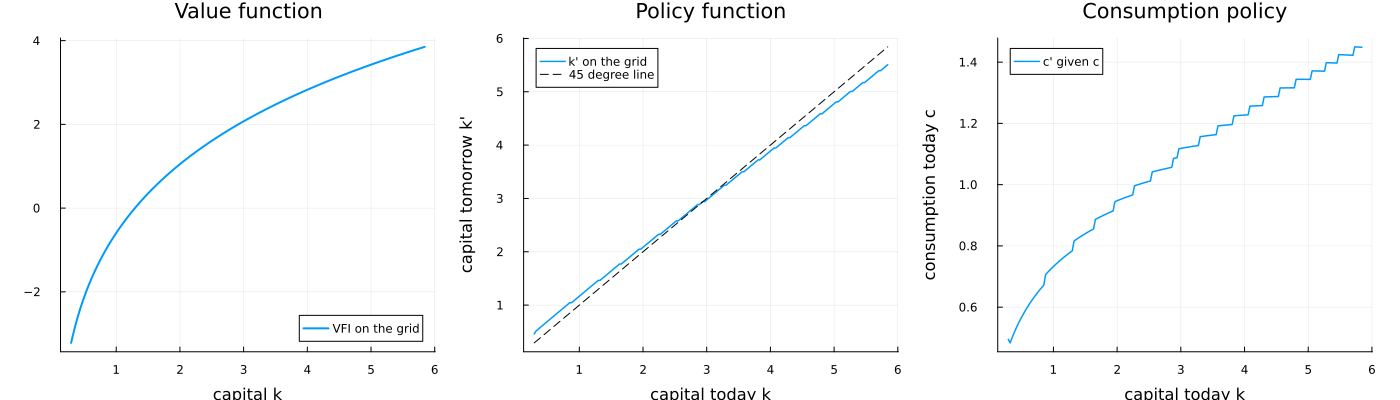

In [15]:
# Plot the value function, the policy function with the 45 degree line, and the consumption policy
p1 = plot(gri.k, v, linewidth = 2, label = "VFI on the grid", legend = :bottomright,
          xlabel = "capital k", title = "Value function")

p2 = plot(gri.k, kprime, linewidth = 1.5, label = "k' on the grid", legend = :topleft,
          xlabel = "capital today k", ylabel = "capital tomorrow k'", title = "Policy function")
plot!(p2, gri.k, gri.k, color = :black, linestyle = :dash, label = "45 degree line")

p3 = plot(gri.k, c, linewidth = 1.5, label = "c' given c", legend = :topleft,
          xlabel =  "capital today k", ylabel = "consumption today c", title = "Consumption policy")

plot(p1, p2, p3, layout = (1, 3), size = (1400, 400), margin = 5Plots.mm)

In [16]:
# Read off where the policy crosses the 45 degree line and compare with k∗ from (6).

idx = argmin(abs.(kprime .- gri.k))  # finds the point on the grid where k' is closest to k
crossing = gri.k[idx]
println("The policy crosses the 45 degree line at the following k:\n ", crossing)
println("The steady state k* value is:\n ", kstar)


The policy crosses the 45 degree line at the following k:
 2.885596154185609
The steady state k* value is:
 2.9208221499640703


The Euler equation error is the largest, in absolute value, at the 1st point on the grid.

The reason for this fact is that we have constructed a grid that has the levels of k that are equidistant, i.e. we always have the same $\Delta k$ from one level of k to the other. When k is very small, the same $\Delta k$ represents a much larger percentage change than when k is large: $\frac{\Delta k}{k small} > \frac{\Delta k}{k large}$. Hence the grid is relatively coarses at the lower end and this, coupled with the fact that the numerical policy k' is constrained to lie on the grid, translates into the approximation of the true policy k' to be worse for small values of k.

In [17]:
delta = gri.k[2]-gri.k[1]
reldelta_start = 100 * (delta / gri.k[1])
reldelta_end = 100 * (delta / gri.k[end])
println("The relative delta at the beginning of the grid is: ", reldelta_start,"%")
println("The relative delta at the end of the grid is: ", reldelta_end,"%")

The relative delta at the beginning of the grid is: 9.547738693467332%
The relative delta at the end of the grid is: 0.4773869346733666%


#### 2.2 (a) Simulate the path of capital over 300 periods starting from k0 = 0.5 k*, using the g policy function obtained in 2.1 (e)

In [18]:
k0 = 0.5*kstar
i = [argmin(abs.(gri.k .- k0))]         # grid index of the point closest to k0
println("Capital starts at grid value k = ",gri.k[i[1]])

T = 300

for t in 1:T
    i_next = g[i[end]]        # read off tomorrow's index from g, corresponding to current grid point gri.k[i0] --> i_t stores the index for k'
    #k_next = gri.k[i_next]       # extract k'
    push!(i, i_next)
end

kpath = gri.k[i]

Capital starts at grid value k = 1.4633465746302403


301-element Vector{Float64}:
 1.4633465746302403
 1.6027828079199822
 1.7422190412097243
 1.853768027841518
 1.9653170144733116
 2.0489787544471567
 2.1326404944210022
 2.2163022343948473
 2.2999639743686924
 2.3557384676845894
 ⋮
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609
 2.885596154185609

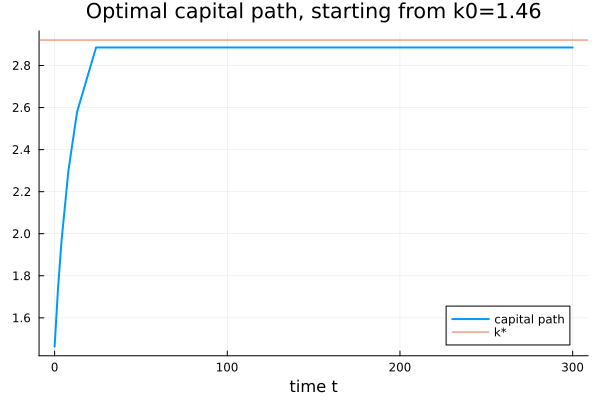

The path settles at k= 2.8856 , its distance to k* being equal to 0.0352

In [19]:
t = 0:T

p1 = plot(t,kpath,linewidth = 2, label = "capital path", legend = :bottomright,
          xlabel = "time t", title = "Optimal capital path, starting from k0=1.46")
hline!(p1, [kstar], label = "k*")

display(p1)

@printf("The path settles at k= %.4f , its distance to k* being equal to %.4f",kpath[end],abs(kpath[end]-kstar))

#### 2.2 (b) Solve the model with N ∈ (50,200,800)

In [20]:
results = NamedTuple[]

N = [50, 200, 800]

for n in N

    mpar2 = NumericalParameters(nk=n)
    
    # ----- runtime and grispacing ----
    t0 = time()
    v, g, iterVF, distVF, gri, kstar = solver(par2, mpar2)
    runtime = time() - t0
    gridspace = gri.k[2] - gri.k[1]

    # ----- max Euler error ------
    kprime = gri.k[g]
    c = gri.k .^ par2.α .+ (1-par2.δ) .* gri.k .- kprime
    cprime = c[g]

    e = Euler_err(kprime, c, cprime, par2)
    maxerr = maximum(abs.(e))

    # ----- point where capital path settles, k0=0.5k* ------
    i = [argmin(abs.(gri.k .- k0))]
    
    for t in 1:T
        i_next = g[i[end]]
        push!(i, i_next)
    end

    kpath = gri.k[i]
    ksettle = kpath[end]

    # ----- Add row to the table ------
    push!(results, (N=n, grid_spacing=round(gridspace,digits=3), iterations=iterVF, runtime=round(runtime,digits=10), max_Euler_error = round(maxerr,digits=3), longrun_capital=round(ksettle,digits=3)))
end

display(results)


Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 50, crit = 1e-06
Iterations: 230
Final distance: 9.667e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 200, crit = 1e-06
Iterations: 226
Final distance: 9.804e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1e-06
Iterations: 226
Final distance: 9.622e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


3-element Vector{NamedTuple}:
 (N = 50, grid_spacing = 0.113, iterations = 230, runtime = 0.0020000935, max_Euler_error = 0.165, longrun_capital = 2.784)
 (N = 200, grid_spacing = 0.028, iterations = 226, runtime = 0.103000164, max_Euler_error = 0.046, longrun_capital = 2.886)
 (N = 800, grid_spacing = 0.007, iterations = 226, runtime = 0.8959999084, max_Euler_error = 0.011, longrun_capital = 2.911)

Rate at which the following objects change as the number of grid points N gets large.

- Runtime: 

In each value function iteration, every current state k is compared to N possible choices of k' -> in each iteration, $N^2$ combinations are evaluated.
Keeping the number of iterations fixed, as N increases the total run time also scales approximately by $N^2$.

Checking this order against the table: 
N scales by a factor of 4, then run time should scale by a factor of 16: 0.927 / 0.034 = 27 > 16
Unfortunately, this is because our runtime is measuring the time for the whole solver() loop (including the grid mesh construction), rather than only the VFI loop runtime.

- Maximum Euler error: 

Since the error comes from forcing the optimal k' onto the nearest grid point, the policy approximation error is of order $N^{-1}$. This means that when N increases x4, the Euler maximum error should fall by a factor of 4.

From the table result, we can see how the maximum Euler error scales by roughly 0.25 (namely, 1/4) as N quadruples: 0.046 / 0.165 = 0.278 and 0.011/0.046 = 0.239.

#### 2.2 (c) Which N would bring the maximum Euler error below $10^{-4}$?

$\frac{err_{Nx}}{err_{800}} = \frac{\frac{Constant}{Nx}}{\frac{Constant}{800}} = \frac{800}{Nx}$

$\rightarrow      10^{-4} = err_{800} * \frac{800}{Nx} $

$\rightarrow      Nx = err_{800} * \frac{800}{10^{-4}} $

In [21]:
N_new = round(results[3].max_Euler_error * results[3].N / (10^(-4)), digits=1)
println("To bring the maximum Euler equation error below 10^-4, we would need a k grid with ", N_new," points.")

To bring the maximum Euler equation error below 10^-4, we would need a k grid with 88000.0 points.


$ runtime_x = runtime_{800} * (\frac{N_{new}}{800})^2 $ 

In [22]:
runtime_new = results[3].runtime * (N_new / results[3].N)^2
println("As a result, the run time would increase to ", round(runtime_new/(60^2),digits=2)," hours.")

As a result, the run time would increase to 3.01 hours.


#### 2.2 (d) Solve the model for $\gamma \in (1,2,5)$

Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 1.0, delta = 0.1, N = 800, crit = 1e-06
Iterations: 156
Final distance: 9.735e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 2.0, delta = 0.1, N = 800, crit = 1e-06
Iterations: 226
Final distance: 9.622e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
Value function iteration with parameters alpha = 0.3, beta = 0.96, gamma = 5.0, delta = 0.1, N = 800, crit = 1e-06
Iterations: 247
Final distance: 9.657e-07
policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states
For an economy with gamma= 1.0, convergence within 5% of steady state capital 2.77 takes the following number of periods: 15
For an economy with gamma= 2.0, convergence within 5% of steady state capital 2.77 takes the following number of periods: 22
For an economy with g

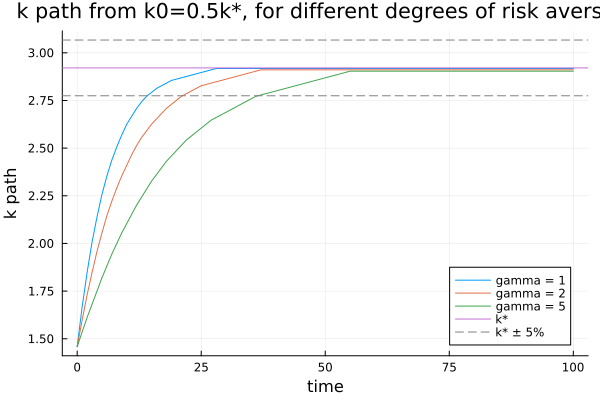

101×3 Matrix{Float64}:
 1.45895  1.45895  1.45895
 1.66732  1.59786  1.53535
 1.8479   1.72983  1.61175
 2.00765  1.8479   1.68121
 2.13962  1.95903  1.75067
 2.2577   2.05627  1.82012
 2.35494  2.14657  1.88263
 2.43828  2.22297  1.94514
 2.50774  2.29242  2.00071
 2.57025  2.35494  2.05627
 ⋮                 
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364
 2.91753  2.91059  2.90364

In [23]:
T = 100

gamma = [1, 2, 5]
mpar = NumericalParameters(nk = 800)

A = zeros(T+1, length(gamma))   # matrix to store the kpath for each gamma

p = plot(xlabel = "time", ylabel = "k path", title = "k path from k0=0.5k*, for different degrees of risk aversion")
n = []  # number of periods it take for an economy to have its capital converge within 5% of steady state capital

for l in gamma

    par3 = EconomicParameters(γ = l, δ = 0.1)

    v, g, iterVF, distVF, gri, kstar = solver(par3, mpar)

    # ----- simulate the path from k0=0.5k* for each gamma ------
    k0 = 0.5 * kstar
    i = [argmin(abs.(gri.k .- k0))]
    
    for t in 1:T
        i_next = g[i[end]]
        push!(i, i_next)
    end

    kpath = gri.k[i]
    aux = findfirst(gamma .== l)
    A[:, aux] = kpath

    t = 0:T
    plot!(p, t, kpath, label = "gamma = $l")

    k095 = 0.95 * kstar
    idx = findfirst(kpath .- k095 .>= 0)
    num = idx - 1                       # since kpath[1] corresponds to t=0
    push!(n,num)

end

hline!(p, [kstar], label = "k*")
hline!(p, [0.95 * kstar], color = :gray, linestyle = :dash, label = "k* ± 5%")
hline!(p, [1.05 * kstar], color = :gray, linestyle = :dash, label = false)
display(p)

@printf("For an economy with gamma= %.1f, convergence within 5%% of steady state capital %.2f takes the following number of periods: %d\n", gamma[1], 0.95*kstar , n[1])
@printf("For an economy with gamma= %.1f, convergence within 5%% of steady state capital %.2f takes the following number of periods: %d\n", gamma[2], 0.95*kstar , n[2])
@printf("For an economy with gamma= %.1f, convergence within 5%% of steady state capital %.2f takes the following number of periods: %d\n", gamma[3], 0.95*kstar , n[3])

display(A)

    

#### 2.2 (e) Which household reaches the steady state fastest, and why? 

In [24]:
# intertemporal elasticity of substitution 1/gamma and 
# saving rate at k0: (k1 - (1-delta)k0) / k0^alpha

elast_subst = []
sav_rate = []
par2 = EconomicParameters(δ = 0.1)

for pos in 1:3
    el = 1/gamma[pos]
    
    k0 = A[1, pos]
    k1 = A[2,pos]
    s = (k1 - (1 - par2.δ)*k0) / (k0^par2.α)

    push!(elast_subst,el)
    push!(sav_rate,s)
end

display(elast_subst)
display(sav_rate)





3-element Vector{Any}:
 1.0
 0.5
 0.2

3-element Vector{Any}:
 0.3163114471560367
 0.2542959947159924
 0.19848208751995255

Households with the highest intertemporal elasticity of substitution (IES) of 1.0 are the fastest in reaching the steady state: it only takes them 15 periods for their capital to get within 5% of k*, while for households with the lower IES of 0.2 it takes them 37 periods.

The reason is that a high IES means that the consumption smoothing motive is weak and moving consumption across periods in response to returns is not very costly.
In our model, since initial capital k0 is below the steady state, the return to saving is relatively high. Thus households with higher IES responds more strongly to the high return and save a higher portion of their income, thus raising k1 more strongly. This is visibile in the pattern of the saving rate at k0: the saving rate for a high-IES household lies at 32% while it equals 20% for a low-IES household.